In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
def load_airline_data():
    print("Loading airline data...")
    df = pd.read_csv("us_airlines.csv")
    print(f"Airline data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    return df

def clean_airline_data(df):
    #df = df.copy()
    print("\nCleaning airline data...")

    # Drop Ref column as it is not useful
    if "Ref" in df.columns:
        df.drop(columns=["Ref"], inplace=True)

    # Drop rows where Airline is missing
    df.dropna(subset=["Airline"], inplace=True)
    df = df[df["Airline"].str.strip() != ""]

    # Clean ASM columns (Available Seat Miles)
    asm_cols = [c for c in df.columns if c.startswith("ASM_")]
    for col in asm_cols:
        df[col] = df[col].astype(str).str.replace(",", "").str.strip()
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Clean Passenger columns
    passenger_cols = [c for c in df.columns if c.startswith("Passengers_")]
    for col in passenger_cols:
        df[col] = df[col].astype(str).str.replace(",", "").str.strip()
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Clean Destinations and Daily departures
    for col in ["Destinations", "Daily departures"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(",", "").str.strip()
            df[col] = pd.to_numeric(df[col], errors="coerce")
            

    # Clean Rank
    if "Rank" in df.columns:
        df["Rank"] = pd.to_numeric(df["Rank"], errors="coerce") #so that we can perform operations like sort on rank coln
    
    # Remove duplicates
    before = df.shape[0]
    df.drop_duplicates(inplace=True)
    print(f"Removed {before - df.shape[0]} duplicate rows")

    df.reset_index(drop=True, inplace=True)
    print(f"Clean airline data: {df.shape[0]} rows, {df.shape[1]} columns")
    return df



def analyze_airlines(df):
    print("\n===== AIRLINE ANALYSIS =====")


    if "ASM_2025" in df.columns:
        print("\nTop Airlines by ASM (2025):")
        top = (df[["Airline", "ASM_2025"]].dropna().sort_values("ASM_2025", ascending=False))
        print(top.to_string(index=False))

    if {"ASM_2025", "ASM_2020"}.issubset(df.columns):
        print("\nTop Airlines by ASM Growth Since 2020:")
        growth = df[["Airline", "ASM_2020", "ASM_2025"]].copy().dropna()
        growth = growth[growth["ASM_2020"] > 0]
        growth["ASM Growth %"] = (((growth["ASM_2025"] - growth["ASM_2020"])/growth["ASM_2020"])*100).round(2)
        growth = growth.sort_values("ASM Growth %", ascending=False)
        print(growth[["Airline", "ASM Growth %"]].to_string(index=False))
        

    if "Passengers_2025" in df.columns:
        print("\nTop Airlines by 2025 Passenger Count:")
        top = df[["Airline", "Passengers_2025"]].dropna().sort_values(
            "Passengers_2025", ascending=False)
        print(top.to_string(index=False))

    if "Destinations" in df.columns:
        print("\nTop Airlines by Destinations:")
        top = df[["Airline", "Destinations"]].dropna().sort_values(
            "Destinations", ascending=False)
        print(top.to_string(index=False))

    if "Daily departures" in df.columns:
        print("\nTop Airlines by Daily Departures:")
        top = df[["Airline", "Daily departures"]].dropna().sort_values(
            "Daily departures", ascending=False)
        print(top.to_string(index=False))

In [44]:
def visualize_airlines(df):
    print("\nGenerating visualizations...")
    fig, axs = plt.subplots(2,2, figsize = (16,12))

    # 1. Top Airlines by ASM
 
    if "ASM_2025" in df.columns:

        temp = df.sort_values("ASM_2025", ascending=False)

        axs[0,0].bar(temp["Airline"], temp["ASM_2025"])
        axs[0,0].set_title("Top Airlines by ASM (2025)")
        axs[0,0].tick_params(axis = "x", rotation = 45)
        axs[0,0].set_xlabel("Airline")
        axs[0,0].set_ylabel("Available Seat Miles (Billions)")


    # 2. ASM Trends (Top 5 Airlines)
   
    asm_cols = ["ASM_2020","ASM_2021","ASM_2022","ASM_2023","ASM_2024","ASM_2025"]

    if all(col in df.columns for col in asm_cols):

        top5 = df.nlargest(5, "ASM_2025")

        for _, row in top5.iterrows():
            axs[0,1].plot(asm_cols,row[asm_cols],marker="o",label=row["Airline"])
            axs[0,1].set_title("ASM Trends of Top 5 Airlines (2020-2025)")
            axs[0,1].legend(fontsize=8)
            axs[0,1].set_xlabel("Year")
            axs[0,1].set_ylabel("Available Seat Miles (Billions)")
            
    
    # 3. Top Airlines by Destinations

    if "Destinations" in df.columns:

        temp = df.sort_values("Destinations", ascending=False)

        axs[1,0].bar(temp["Airline"],temp["Destinations"])
        axs[1,0].set_title("Top Airlines by Destinations")
        axs[1,0].tick_params(axis = "x", rotation = 45)
        axs[1,0].set_xlabel("Airline")
        axs[1,0].set_ylabel("Number of Destinations")

   
    # 4. Destinations vs Daily Departures
 
    if {"Destinations", "Daily departures"}.issubset(df.columns):
        
        axs[1,1].scatter(df["Destinations"],df["Daily departures"])
        axs[1,1].set_title("Destinations vs Daily Departures")
        axs[1,1].set_xlabel("Destinations")
        axs[1,1].set_ylabel("Daily Departures")
     
    plt.suptitle("US Airlines Dashboard",fontsize=16)
    plt.savefig("airlines_analysis.png", dpi=150, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

    print("Visualizations generated.")

In [45]:
def main():
    airline_df = load_airline_data()
    airline_df_clean = clean_airline_data(airline_df)

    airline_df_clean.to_csv("cleaned_airlines.csv",index=False)
    print("Saved cleaned_airlines.csv")

    analyze_airlines(airline_df_clean)
    visualize_airlines(airline_df_clean)

Loading airline data...
Airline data loaded: 10 rows, 20 columns

Cleaning airline data...
Removed 0 duplicate rows
Clean airline data: 10 rows, 19 columns
Saved cleaned_airlines.csv

===== AIRLINE ANALYSIS =====

Top Airlines by ASM (2025):
             Airline  ASM_2025
     United Airlines       330
   American Airlines       299
     Delta Air Lines       298
  Southwest Airlines       180
          Air Canada       105
     Alaska Airlines       100
             JetBlue        65
    Spirit Airlines†        40
   Frontier Airlines        40
Sun Country Airlines         8

Top Airlines by ASM Growth Since 2020:
             Airline  ASM Growth %
     Alaska Airlines        170.27
     United Airlines        168.29
     Delta Air Lines        122.39
   American Airlines        109.09
Sun Country Airlines        100.00
             JetBlue         96.97
  Southwest Airlines         74.76
    Spirit Airlines†         42.86

Top Airlines by 2025 Passenger Count:
             Airline  P

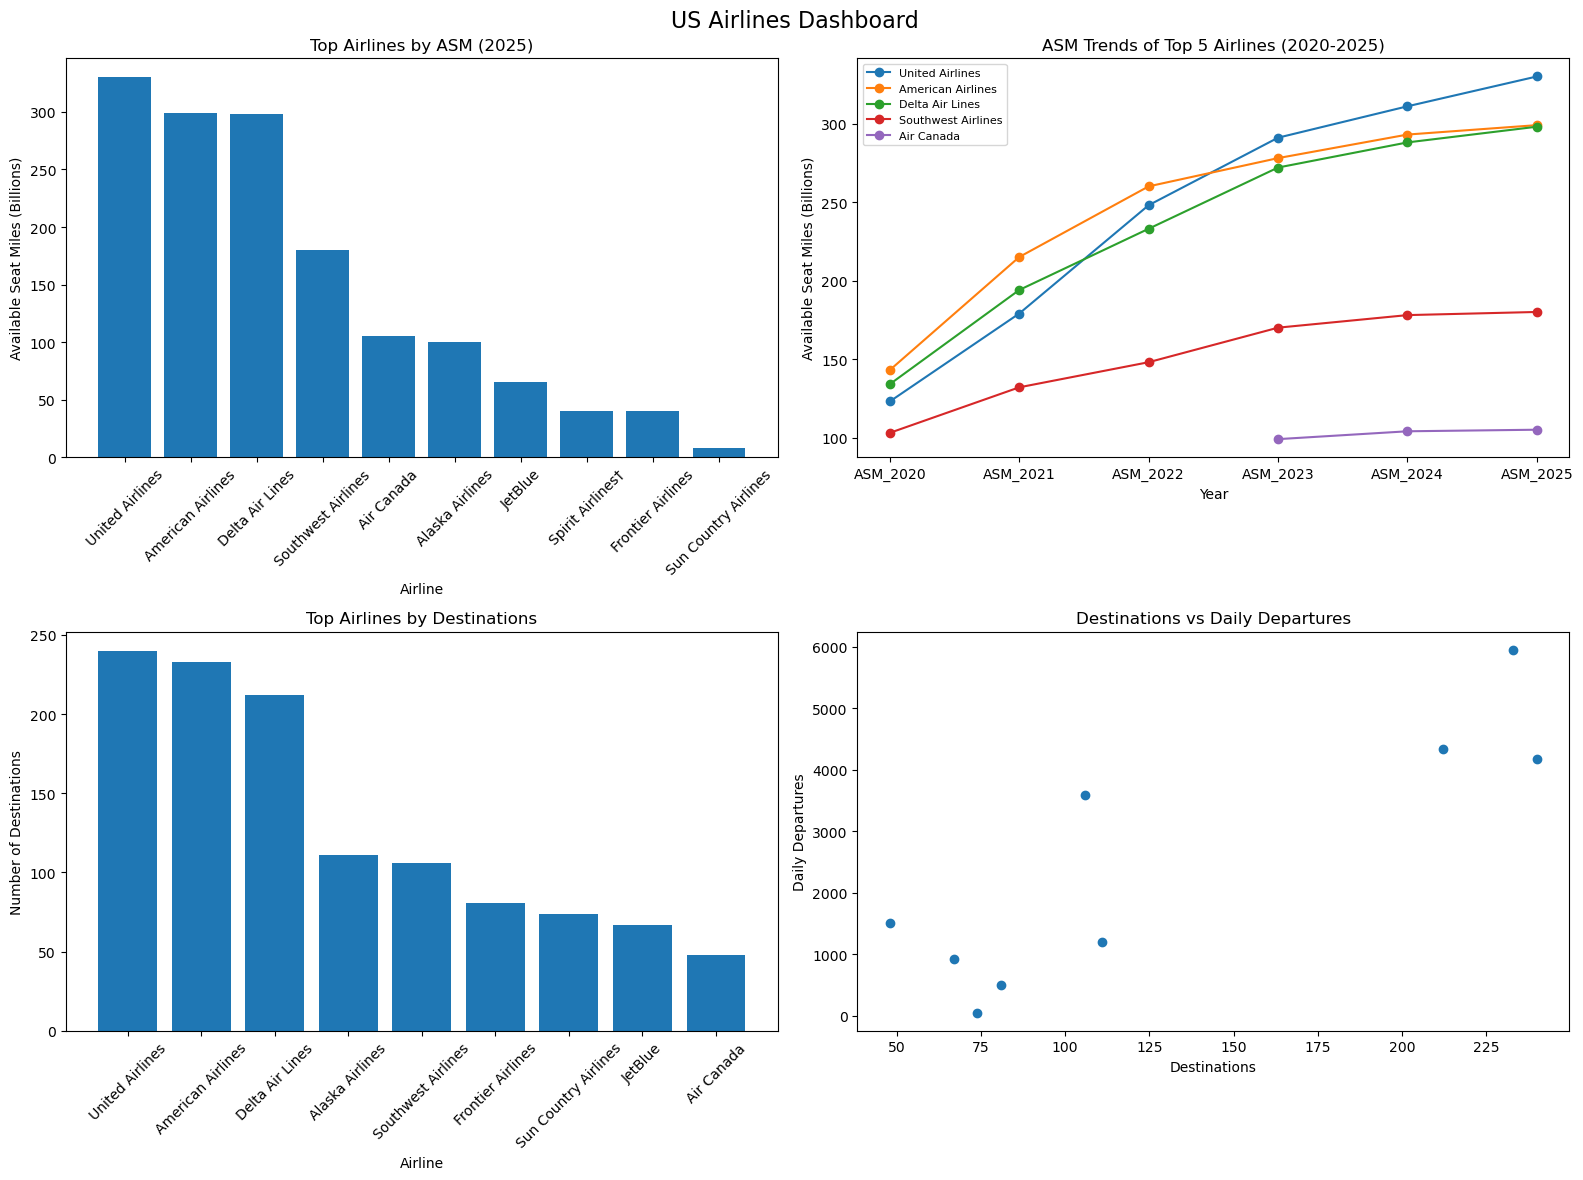

Visualizations generated.


In [46]:
if __name__ == "__main__":
    main()